### 0. Instrucciones Generales

* El taller se desarrolla en Google Colab usando una GPU gratuita de NVIDIA.
* Se trabaja en parejas; ambos integrantes deben entender cada parte.
* Se deben capturar pantallazos de cada salida importante indicada con [PANTALLAZO].
* Al finalizar, se descarga el notebook y se sube todo a un repositorio de GitHub.

### Preguntas
1. ¿Qué diferencia hay entre un notebook en la nube (Colab) y un entorno local como el del tutorial de instalación? ¿Cuál prefieren y por qué?
2. Antes de comenzar, hagan una predicción: ¿cuántas veces más rápida creen que será la GPU comparada con la CPU en el entrenamiento? Anoten su predicción aquí y compárenla al final con el resultado real.

## 1. Configurar el Entorno en Google Colab
* Activar la GPU desde el menú de Colab: Entorno de ejecución > Cambiar tipo de entorno de ejecución.
* Verificar que PyTorch reconoce la GPU y mostrar el nombre del dispositivo.
* Ejecutar `nvidia-smi` para ver el estado de la GPU, igual que en el tutorial de instalación.

In [75]:
# Celda 1: Verificar GPU disponible
import torch

print('Version de PyTorch:', torch.__version__)
print('GPU disponible:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('Nombre de la GPU:', torch.cuda.get_device_name(0))
    print('Memoria total (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print('No hay GPU. Revisa que activaste el acelerador correctamente.')



Version de PyTorch: 2.10.0+cu128
GPU disponible: True
Nombre de la GPU: Tesla T4
Memoria total (GB): 15.64


In [76]:
!nvidia-smi

Mon May 25 20:56:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             26W /   70W |     171MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Preguntas
1. La salida de `nvidia-smi` muestra campos como *Driver Version*, *Memory Usage* y *GPU-Util*. ¿Qué indica cada uno?
2. Cuando activan el acelerador en Colab, ¿qué creen que ocurre físicamente? ¿La GPU está en su computador o en otro lugar? Propongan una analogía con algo de la vida cotidiana.
3. `torch.cuda.is_available()` retorna `True` o `False`. ¿Qué condiciones deben cumplirse para que retorne `True`? Listen al menos tres requisitos.

### 2. Conceptos: CPU vs GPU en PyTorch
* Comparar las operaciones de CUDA en C con su equivalente en PyTorch.
* Entender cómo se mueven tensores entre CPU y GPU con `.to('cuda')`.
* Definir el dispositivo al inicio del proyecto para que el código funcione con o sin GPU.


In [77]:
# Celda 3: Tensores en CPU vs GPU
import torch

# Crear un tensor en CPU (memoria del procesador)
tensor_cpu = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print('Tensor en CPU:', tensor_cpu)
print('Dispositivo:', tensor_cpu.device)   # Debe decir: cpu

# Mover el tensor a la GPU (memoria de la tarjeta grafica)
# Esto es equivalente a cudaMemcpy(CPU -> GPU) del tutorial
tensor_gpu = tensor_cpu.to('cuda')
print('Tensor en GPU:', tensor_gpu)
print('Dispositivo:', tensor_gpu.device)   # Debe decir: cuda:0

# Las operaciones en GPU se ejecutan en paralelo automaticamente
resultado = tensor_gpu * 2
print('Resultado (en GPU):', resultado)
print('Dispositivo resultado:', resultado.device)

Tensor en CPU: tensor([1., 2., 3., 4., 5.])
Dispositivo: cpu
Tensor en GPU: tensor([1., 2., 3., 4., 5.], device='cuda:0')
Dispositivo: cuda:0
Resultado (en GPU): tensor([ 2.,  4.,  6.,  8., 10.], device='cuda:0')
Dispositivo resultado: cuda:0


In [78]:
# Celda 4: Definir dispositivo (SIEMPRE al inicio del proyecto)
import torch

# Esta linea elige GPU si hay, CPU si no hay
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo a usar:', device)

# A partir de aqui, todo se envia a 'device'
# No escribimos 'cuda' directamente, usamos la variable device

Dispositivo a usar: cuda


### Preguntas
1. En el tutorial anterior usaron `cudaMemcpy` para mover datos entre CPU y GPU. En PyTorch eso se hace con `.to('cuda')`. ¿Qué ventaja le ven a la forma de PyTorch? ¿Qué se pierde al abstraerlo tanto?
2. Diagramen en Excalidraw el flujo de un tensor desde que se crea en CPU hasta que se opera en GPU y el resultado vuelve a CPU. Etiqueten cada flecha con la operación de PyTorch correspondiente.
3. ¿Por qué es una buena práctica usar la variable `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')` en lugar de escribir `'cuda'` directamente en el código?

### 3. Preparar los Datos: Dataset MNIST
* Descargar el dataset MNIST: 60,000 imágenes de entrenamiento y 10,000 de prueba.
* Aplicar transformaciones para convertir las imágenes a tensores y normalizarlas.
* Visualizar una muestra del dataset para entender qué se va a clasificar.

In [79]:
# Celda 5: Importar librerias necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Definir el dispositivo (de la celda anterior)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando dispositivo:', device)

Usando dispositivo: cuda


In [80]:
# Celda 6: Descargar y preparar los datos

# transform: convierte las imagenes a tensores y las normaliza
# Normalizar significa ajustar los valores para que el entrenamiento sea estable
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # media y desv. estandar de MNIST
])

# Descargar datos de entrenamiento (60,000 imagenes)
train_dataset = datasets.MNIST(root='./data', train=True,
                               download=True, transform=transform)

# Descargar datos de prueba (10,000 imagenes)
test_dataset  = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

# DataLoader: carga los datos en lotes (batches) para entrenar de a poco
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Forma de un lote: torch.Size([64, 1, 28, 28])


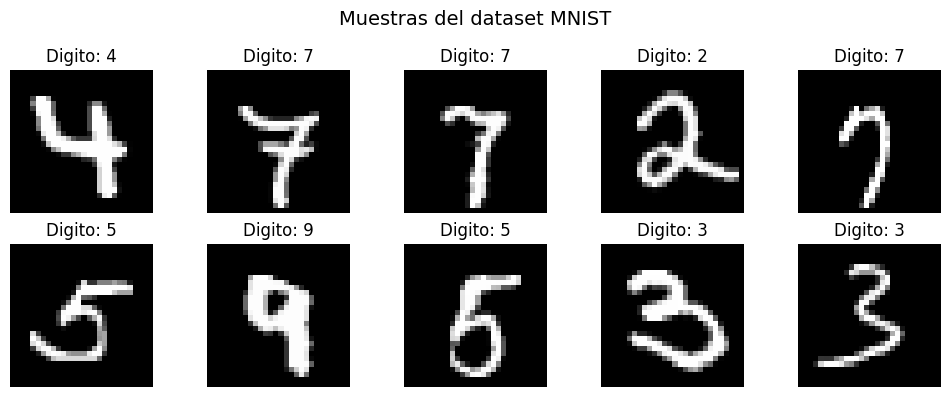

In [81]:
# Celda 7: Ver algunas imagenes del dataset
imagenes, etiquetas = next(iter(train_loader))

print('Forma de un lote:', imagenes.shape)  # [64, 1, 28, 28]
# 64 = batch_size, 1 = canal (escala de grises), 28x28 = tamano imagen

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes[i].squeeze(), cmap='gray')
    ax.set_title(f'Digito: {etiquetas[i].item()}')
    ax.axis('off')
plt.suptitle('Muestras del dataset MNIST', fontsize=14)
plt.tight_layout()
plt.show()

### Preguntas
1. El dataset se divide en 60,000 imágenes de entrenamiento y 10,000 de prueba. ¿Por qué no se entrena con todas las 70,000? Propongan una analogía con estudiar para un examen.
2. El `DataLoader` carga los datos en lotes (*batches*) de 64 imágenes. ¿Por qué no se pasan todas las imágenes de una sola vez a la GPU? Relacionen su respuesta con el concepto de memoria que vieron en `nvidia-smi`.
3. Cada imagen tiene forma `[1, 28, 28]`. Diagramen en Excalidraw qué representa cada dimensión y cómo luce ese tensor visualmente.

### 4. Construir la Red Neuronal
* Definir la arquitectura: capa de entrada (784), dos capas ocultas (256 y 128), capa de salida (10 dígitos).
* Mover el modelo a la GPU con `.to(device)`.
* Contar el total de parámetros entrenables de la red.

In [82]:
# Celda 8: Definir la arquitectura de la red neuronal

class RedNeuronal(nn.Module):
    def __init__(self):
        super(RedNeuronal, self).__init__()
        # Definir las capas de la red
        self.capas = nn.Sequential(
            nn.Flatten(),          # Aplana 28x28 = 784 valores
            nn.Linear(784, 256),   # Capa 1: entrada(784) -> oculta(256)
            nn.ReLU(),             # Funcion de activacion
            nn.Linear(256, 128),   # Capa 2: oculta(256) -> oculta(128)
            nn.ReLU(),             # Funcion de activacion
            nn.Linear(128, 10),    # Capa 3: oculta(128) -> salida(10 digitos)
        )

    def forward(self, x):
        return self.capas(x)

# Crear la red y moverla a la GPU
# Esto es equivalente a cudaMalloc para los pesos de la red
modelo = RedNeuronal().to(device)

print('Arquitectura de la red:')
print(modelo)
print()

# Contar parametros entrenables
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Total de parametros: {total_params:,}')


Arquitectura de la red:
RedNeuronal(
  (capas): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total de parametros: 235,146


### Preguntas
1. Diagramen en Excalidraw la arquitectura completa de la red: entrada → capa 1 → capa 2 → salida. Indiquen el número de neuronas en cada capa y qué función de activación se usa entre ellas.
2. ¿Por qué la capa de entrada tiene exactamente 784 neuronas y la de salida exactamente 10? ¿Qué pasaría si pusieran 11 neuronas en la salida?
3. Cuando hacen `modelo.to(device)`, ¿qué creen que se está transfiriendo a la GPU? ¿Es solo el código, o algo más? Propongan una analogía con el tutorial de CUDA en C.

### 5. Entrenar el Modelo: CPU vs GPU
* Entrenar el mismo modelo dos veces: primero en CPU, luego en GPU.
* Medir el tiempo de entrenamiento en cada dispositivo.
* Comparar los resultados y calcular cuántas veces más rápida fue la GPU.

In [83]:
def entrenar_con_loss(modelo, train_loader, test_loader, dispositivo, title, epocas=3):
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=0.001)

    historico_train = []
    historico_test  = []

    modelo.train()
    inicio = time.time()

    for epoca in range(epocas):
        # --- Training loss ---
        modelo.train()
        loss_train = 0
        for imagenes, etiquetas in train_loader:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            prediccion = modelo(imagenes)
            perdida = criterio(prediccion, etiquetas)

            optimizador.zero_grad()
            perdida.backward()
            optimizador.step()

            loss_train += perdida.item()

        # --- Test loss ---
        modelo.eval()
        loss_test = 0
        with torch.no_grad():
            for imagenes, etiquetas in test_loader:
                imagenes = imagenes.to(dispositivo)
                etiquetas = etiquetas.to(dispositivo)
                prediccion = modelo(imagenes)
                perdida = criterio(prediccion, etiquetas)
                loss_test += perdida.item()

        avg_train = loss_train / len(train_loader)
        avg_test  = loss_test  / len(test_loader)

        historico_train.append(avg_train)
        historico_test.append(avg_test)

        print(f"Epoca {epoca+1}/{epocas} - Train loss: {avg_train:.4f} | Test loss: {avg_test:.4f}")

    tiempo = time.time() - inicio

    # --- Graficar ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epocas+1), historico_train, label='Training loss', linewidth=2)
    plt.plot(range(1, epocas+1), historico_test,  label='Test loss',     linewidth=2, linestyle='--')
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    plt.title(f'Curva de Aprendizaje {title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return historico_train, historico_test, tiempo

ENTRENAMIENTO EN CPU
Epoca 1/3 - Train loss: 0.2305 | Test loss: 0.1198
Epoca 2/3 - Train loss: 0.0969 | Test loss: 0.0889
Epoca 3/3 - Train loss: 0.0669 | Test loss: 0.0900


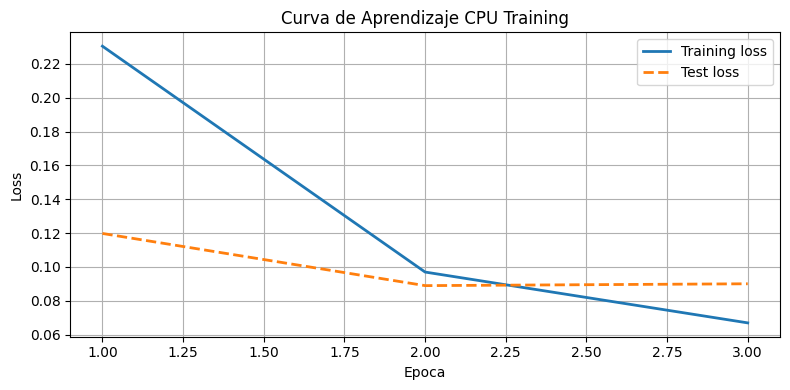

Tiempo total en CPU: 48.86 segundos


In [84]:
# Celda 10: Entrenamiento en CPU
print('=' * 50)
print('ENTRENAMIENTO EN CPU')
print('=' * 50)

# Crear nuevo modelo en CPU
modelo_cpu = RedNeuronal().to('cpu')

_, _, tiempo_cpu = entrenar_con_loss(modelo_cpu, train_loader, test_loader, 'cpu', 'CPU Training', epocas=3)
print(f'Tiempo total en CPU: {tiempo_cpu:.2f} segundos')

ENTRENAMIENTO EN GPU
Epoca 1/3 - Train loss: 0.2326 | Test loss: 0.1108
Epoca 2/3 - Train loss: 0.0932 | Test loss: 0.0778
Epoca 3/3 - Train loss: 0.0661 | Test loss: 0.0801


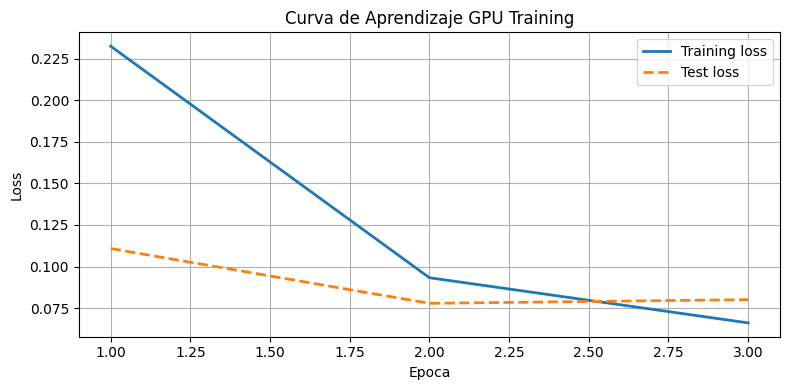

Tiempo total en GPU: 45.15 segundos


In [85]:
# Celda 11: Entrenamiento en GPU
print('=' * 50)
print('ENTRENAMIENTO EN GPU')
print('=' * 50)

# Crear nuevo modelo en GPU
modelo_gpu = RedNeuronal().to('cuda')

_, _, tiempo_gpu = entrenar_con_loss(modelo_gpu, train_loader, test_loader, 'cuda', 'GPU Training', epocas=3)
print(f'Tiempo total en GPU: {tiempo_gpu:.2f} segundos')

In [86]:
# Celda 12: Comparacion CPU vs GPU
print('\n' + '=' * 50)
print('COMPARACION DE RENDIMIENTO')
print('=' * 50)
print(f'Tiempo en CPU:  {tiempo_cpu:.2f} segundos')
print(f'Tiempo en GPU:  {tiempo_gpu:.2f} segundos')
aceleracion = tiempo_cpu / tiempo_gpu
print(f'La GPU fue {aceleracion:.1f}x mas rapida que la CPU')
# Ver memoria de GPU usada durante entrenamiento
print(f'\nMemoria GPU usada: {torch.cuda.max_memory_allocated()/1e6:.1f} MB')
!nvidia-smi


COMPARACION DE RENDIMIENTO
Tiempo en CPU:  48.86 segundos
Tiempo en GPU:  45.15 segundos
La GPU fue 1.1x mas rapida que la CPU

Memoria GPU usada: 26.8 MB
Mon May 25 20:57:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             26W /   70W |     171MiB /  15360MiB |      1%

### Preguntas
1. Registren aquí los tiempos obtenidos. ¿El resultado coincidió con la predicción que hicieron en la sección 0? ¿Qué los sorprendió?
2. El entrenamiento repite el ciclo: *predicción → error → ajuste de pesos*. Propongan una analogía con algo cotidiano que siga el mismo ciclo de mejora por repetición.
3. ¿Por qué creen que la GPU es más rápida en esta tarea? Relacionen su respuesta con el concepto de hilos y bloques que vieron en el tutorial de CUDA en C.

### Análisis de la Curva de Aprendizaje

Antes de responder, observen su gráfica generada y usen esta escala para interpretar el Loss:

| Loss final | Interpretación |
|---|---|
| 1.0 o más | La red no aprendió nada, está adivinando al azar |
| 0.3 - 0.5 | Aprendiendo, pero todavía comete muchos errores |
| 0.1 - 0.2 | Bien, la red entiende el problema |
| 0.07 o menos | Muy bien, la red generaliza correctamente |
| 0.01 o menos | Casi perfecto |

**Analogía:** el Training loss son los errores practicando con ejercicios del libro que ya conocen. El Test loss son los errores en el examen real, con preguntas que nunca vieron. Al inicio la red falla mucho con los ejercicios porque no sabe nada, pero como tampoco ha memorizado nada raro, falla de forma pareja en el examen. Conforme avanza, domina los ejercicios y eso se traduce en mejora en el examen real — ahí es donde las dos líneas convergen.

### Preguntas

1. Según la escala, ¿en qué rango quedó el Loss final de su modelo? ¿Lo consideran un buen resultado para 3 épocas? Justifiquen con base en la gráfica que generaron.
2. Observen en qué época convergen las dos líneas. ¿Qué creen que pasaría si entrenaran 2 épocas más — el loss seguiría bajando indefinidamente o en algún punto se detendría? ¿Qué riesgo aparece si se entrena demasiado?

## 6. Evaluar y Visualizar Resultados
* Calcular la precisión del modelo sobre los datos de prueba que nunca vio durante el entrenamiento.
* Visualizar predicciones reales con indicadores de acierto (verde) y error (rojo).

In [87]:
# Celda 13: Evaluar el modelo entrenado en GPU

def evaluar(modelo, loader, dispositivo):
    modelo.eval()  # Modo evaluacion (desactiva dropout, etc.)
    correctas = 0
    total = 0

    with torch.no_grad():  # No calcular gradientes (ahorra memoria)
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            salidas = modelo(imagenes)
            # La prediccion es la clase con mayor valor
            _, prediccion = torch.max(salidas, 1)
            total += etiquetas.size(0)
            correctas += (prediccion == etiquetas).sum().item()

    return 100 * correctas / total

precision_gpu = evaluar(modelo_gpu, test_loader, 'cuda')
precision_cpu = evaluar(modelo_cpu, test_loader, 'cpu')
print(f'Precision del modelo GPU: {precision_gpu:.2f}%')
print(f'Precision del modelo CPU: {precision_cpu:.2f}%')

Precision del modelo GPU: 97.52%
Precision del modelo CPU: 97.34%


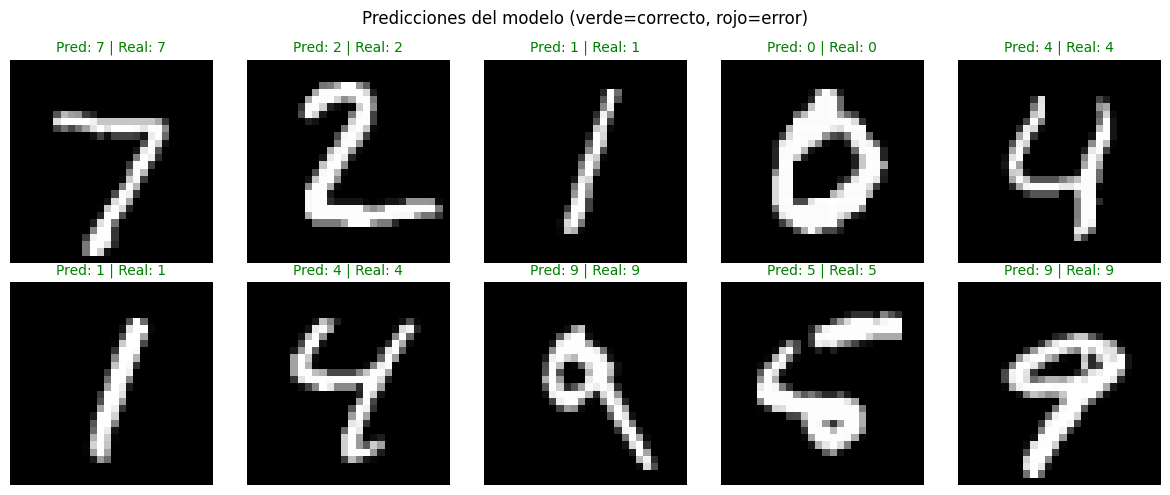

In [88]:
# Celda 14: Visualizar predicciones del modelo GPU
modelo_gpu.eval()
imagenes_test, etiquetas_test = next(iter(test_loader))
imagenes_test = imagenes_test.to('cuda')

with torch.no_grad():
    salidas = modelo_gpu(imagenes_test)
    _, predicciones = torch.max(salidas, 1)
# Traer todo de vuelta a CPU para visualizar
imagenes_test = imagenes_test.cpu()
predicciones  = predicciones.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes_test[i].squeeze(), cmap='gray')
    correcto = predicciones[i] == etiquetas_test[i]
    color = 'green' if correcto else 'red'
    ax.set_title(f'Pred: {predicciones[i]} | Real: {etiquetas_test[i]}',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Predicciones del modelo (verde=correcto, rojo=error)', fontsize=12)
plt.tight_layout()
plt.show()

### Preguntas
1. ¿Por qué la precisión se mide sobre datos que el modelo nunca vio durante el entrenamiento y no sobre los mismos datos con los que aprendió?
2. Observen los dígitos que el modelo clasificó mal. ¿Tienen algo en común? ¿Por qué creen que la red se equivocó en esos casos específicos?
3. Si quisieran mejorar la precisión del modelo, ¿qué cambiarían de la arquitectura o del entrenamiento? Propongan al menos dos modificaciones y justifiquen cada una.

### 7. Prueba tu Propio Dígito
* Dibujar un dígito del 0 al 9 en Paint (o cualquier editor), guardarlo como imagen.
* Subir la imagen a Colab y preprocesarla para que tenga el mismo formato que MNIST: escala de grises, fondo negro, trazo blanco, tamaño 28x28.
* Pasarla al modelo entrenado y ver qué predice.
* Visualizar la imagen tal como la ve la red antes de hacer la predicción.

Saving WhatsApp Image 2026-05-25 at 4.26.59 PM.jpeg to WhatsApp Image 2026-05-25 at 4.26.59 PM (1).jpeg


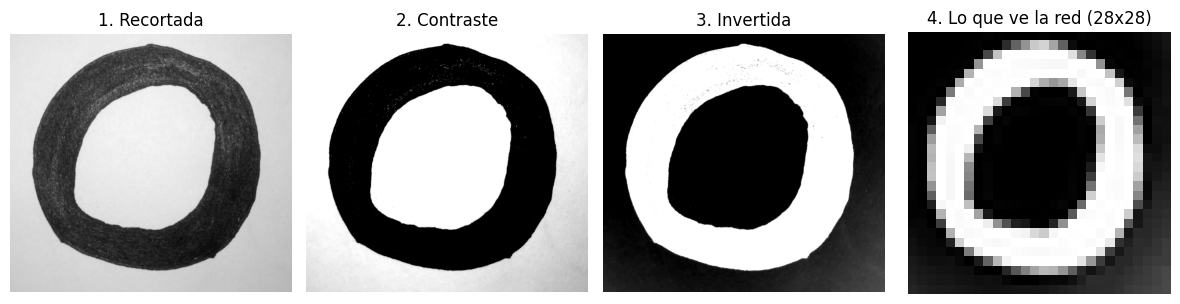

El modelo GPU predice: 0
El modelo CPU predice: 0


In [96]:
from google.colab import files
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

def procesar_imagen(nombre):
    original = Image.open(nombre).convert('L')

    # 1. Recortar bordes (quita sombras y bordes de hoja)
    w, h = original.size
    recortada = original.crop((w*0.05, h*0.05, w*0.95, h*0.95))

    # 2. Aumentar contraste para separar trazo del fondo
    from PIL import ImageEnhance, ImageFilter
    contraste = ImageEnhance.Contrast(recortada).enhance(3.0)

    # 3. Suavizar ruido de arrugas
    suavizada = contraste.filter(ImageFilter.MedianFilter(size=3))

    # 4. Invertir colores (fondo negro, trazo blanco como MNIST)
    invertida = ImageOps.invert(suavizada)
    engrosada = invertida.filter(ImageFilter.MaxFilter(size=3))

    # 5. Escalar a 28x28
    procesada = engrosada.resize((28, 28), Image.LANCZOS)

    # Visualizar las etapas
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    axes[0].imshow(recortada, cmap='gray')
    axes[0].set_title('1. Recortada')
    axes[0].axis('off')

    axes[1].imshow(contraste, cmap='gray')
    axes[1].set_title('2. Contraste')
    axes[1].axis('off')

    axes[2].imshow(invertida, cmap='gray')
    axes[2].set_title('3. Invertida')
    axes[2].axis('off')

    axes[3].imshow(np.array(procesada), cmap='gray')
    axes[3].set_title('4. Lo que ve la red (28x28)')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return procesada

subido = files.upload()
nombre = list(subido.keys())[0]

imagen = procesar_imagen(nombre)

# Pasar al modelo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

tensor = transform(imagen).unsqueeze(0).to('cuda')

modelo_gpu.eval()
with torch.no_grad():
    salida = modelo_gpu(tensor)
    prediccion = salida.argmax(dim=1).item()

print(f'El modelo GPU predice: {prediccion}')

modelo_cpu.eval()
with torch.no_grad():
    tensor_cpu = transform(imagen).unsqueeze(0).to('cpu')
    salida = modelo_cpu(tensor_cpu)
    prediccion = salida.argmax(dim=1).item()

print(f'El modelo CPU predice: {prediccion}')

### Preguntas
1. ¿El modelo acertó con tu dígito dibujado a mano? Si falló, ¿por qué creen que se equivocó? Comparen su imagen con las del dataset MNIST — ¿se ven similares o muy diferentes?
2. El preprocesamiento invierte los colores de la imagen (`ImageOps.invert`). ¿Por qué es necesario hacer eso antes de pasarla al modelo? ¿Qué pasaría si no se hiciera?
3. Prueben con un dígito que crean que va a fallar — por ejemplo un 4 o un 9 escritos de forma poco convencional. ¿Falló? ¿Qué dice eso sobre las limitaciones del modelo entrenado solo con MNIST?
4. Tomar captura, de almenos una predicción que se haya hecho correctamente.

### Bonus: ¿Qué tan seguro está el modelo?

Hasta ahora sabemos *qué* predice el modelo, pero no *qué tan seguro* está de su respuesta. Un modelo puede predecir "7" con un 95% de confianza o con un 40% — y eso hace toda la diferencia.

Ejecuten la siguiente celda para ver la distribución de probabilidades sobre los 10 dígitos para ambos modelos. Si el modelo está seguro, un dígito tendrá un porcentaje muy alto y los demás estarán cerca de 0. Si está dudando, verán los porcentajes distribuidos entre varios dígitos.

In [97]:
# Ver qué tan seguro está cada modelo
import torch.nn.functional as F

with torch.no_grad():
    # GPU
    tensor_gpu = transform(imagen).unsqueeze(0).to('cuda')
    salida_gpu = modelo_gpu(tensor_gpu)
    prob_gpu = F.softmax(salida_gpu, dim=1)[0]

    # CPU
    tensor_cpu = transform(imagen).unsqueeze(0).to('cpu')
    salida_cpu = modelo_cpu(tensor_cpu)
    prob_cpu = F.softmax(salida_cpu, dim=1)[0]

print("Probabilidades GPU:")
for i, p in enumerate(prob_gpu):
    print(f"  {i}: {p.item()*100:.1f}%")

print("\nProbabilidades CPU:")
for i, p in enumerate(prob_cpu):
    print(f"  {i}: {p.item()*100:.1f}%")

Probabilidades GPU:
  0: 87.1%
  1: 0.0%
  2: 4.7%
  3: 8.2%
  4: 0.0%
  5: 0.0%
  6: 0.0%
  7: 0.0%
  8: 0.0%
  9: 0.0%

Probabilidades CPU:
  0: 91.0%
  1: 0.0%
  2: 6.3%
  3: 2.5%
  4: 0.0%
  5: 0.1%
  6: 0.0%
  7: 0.0%
  8: 0.0%
  9: 0.0%


**Observen y respondan:**
1. ¿Cuál dígito tiene la probabilidad más alta en cada modelo? ¿Coincide con la predicción?
2. ¿El modelo está seguro o dudando? ¿Cómo lo saben mirando los porcentajes?
3. Si el porcentaje más alto es menor al 50%, ¿confiarían en esa predicción? ¿Por qué?

### 🔍 Nota sobre el rendimiento (CPU vs GPU)

Es posible que hayas notado que la GPU fue solo ligeramente más rápida (~1.1x) que la CPU. Esto **no es un error**, se debe a:

1. **Tamaño del modelo:** Esta red es muy pequeña (235k parámetros). La CPU puede manejarla fácilmente.
2. **Overhead de transferencia:** Mover datos pequeños constantemente entre la RAM y la memoria de video (VRAM) consume tiempo. En modelos grandes (como GPT o ResNet), el cálculo es tan masivo que este tiempo de transferencia se vuelve despreciable.
3. **Latencia de lanzamiento:** Lanzar un kernel de CUDA tiene un costo fijo. Si el trabajo que hace el kernel es muy corto, pasamos más tiempo 'lanzando' que 'ejecutando'.

**Para ver la verdadera potencia de la GPU:** Intenta aumentar el `batch_size` a 1024 o añade muchas más capas a la `RedNeuronal`.